# Arc-welding power-supply circuits: algebra through calculus

A transformer-based arc welder is a real, teachable RL circuit: a step-down
transformer secondary (resistance $R$, leakage inductance $L$) drives an arc
that behaves, to first order, like a load resistance. Same circuit, three
levels of math, matching this repo's usual pipeline
$\text{algebra} \to \text{calculus} \to \text{engineering number}$:

- **Algebra**: Ohm's law $V=IR$ and power $P=IV$ for the arc itself.
- **Calculus** (high-school level): when the electrode strikes the workpiece,
  current doesn't jump instantly -- it rises along the classic first-order RL
  transient, the solution of $L\,di/dt + R\,i = V$.
- **Circuit engineering**: the transformer secondary's AC impedance
  (reusing `dgs/ac_circuits.py` directly), and a practical heat-input formula
  welders actually use.

All of this is `dgs/welding_circuits.py` (16 tests, `tests/test_welding_circuits.py`)
-- this notebook walks through it with real numbers and plots.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # repo root (notebook runs in notebooks/)
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing()

from dgs.welding_circuits import (
    arc_resistance, arc_power, rl_transient_symbolic, rl_transient_current,
    time_to_steady_state, transformer_secondary_impedance,
    open_circuit_to_arc_voltage_drop, heat_input,
)
print("loaded dgs.welding_circuits")

loaded dgs.welding_circuits


## Part 1 -- Algebra: Ohm's law and power for the arc

$$R_{\rm arc} = \frac{V_{\rm arc}}{I_{\rm weld}}, \qquad P_{\rm arc} = V_{\rm arc}\,I_{\rm weld}.$$

`arc_resistance` reuses `dgs/elementary_algebra.py`'s `solve_for_missing_factor`
($ab=c \Rightarrow b=c/a$) rather than reimplementing division -- the same
algebra-level solver this repo uses elsewhere, applied to a new problem.

**What would I actually measure in a lab (or weld shop)?** A clamp-on ammeter
on the electrode cable reads $I_{\rm weld}$; a voltmeter across the arc gap
(or the welder's own front-panel meter) reads $V_{\rm arc}$ -- neither
$R_{\rm arc}$ nor $P_{\rm arc}$ is measured directly, both are computed from
these two readings.

**MATLAB equivalent:** `R = V/I;` -- plain scalar division, no toolbox needed.

**Questions to ask:** Does a HIGHER arc voltage at the SAME current mean a
LONGER arc (yes -- arc length and arc voltage are directly related in stick
welding, which is why voltage is often used as a proxy for arc length)?

V_arc=22.0 V, I_weld=150.0 A
R_arc = V/I = 0.1467 ohm
P_arc = V*I = 3300 W


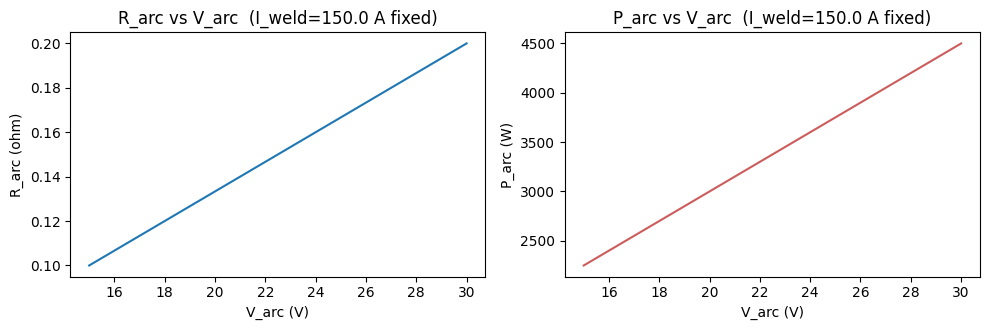

In [2]:
V_arc, I_weld = 22.0, 150.0   # typical SMAW (stick) welding numbers
R_arc = arc_resistance(V_arc, I_weld)
P_arc = arc_power(V_arc, I_weld)
print(f"V_arc={V_arc} V, I_weld={I_weld} A")
print(f"R_arc = V/I = {R_arc:.4f} ohm")
print(f"P_arc = V*I = {P_arc:.0f} W")

# how R_arc and P_arc change as arc voltage varies at fixed current (longer arc)
V_range = np.linspace(15, 30, 50)
R_range = [arc_resistance(v, I_weld) for v in V_range]
P_range = [arc_power(v, I_weld) for v in V_range]

fig, axs = plt.subplots(1, 2, figsize=(10, 3.4))
axs[0].plot(V_range, R_range); axs[0].set_xlabel('V_arc (V)'); axs[0].set_ylabel('R_arc (ohm)')
axs[0].set_title(f'R_arc vs V_arc  (I_weld={I_weld} A fixed)')
axs[1].plot(V_range, P_range, color='indianred'); axs[1].set_xlabel('V_arc (V)'); axs[1].set_ylabel('P_arc (W)')
axs[1].set_title(f'P_arc vs V_arc  (I_weld={I_weld} A fixed)')
plt.tight_layout(); plt.show()

## Part 2 -- Calculus: the RL current-rise transient at arc strike

$$L\frac{di}{dt} + Ri = V \quad\Longrightarrow\quad i(t) = \frac{V}{R}\left(1-e^{-tR/L}\right).$$

`rl_transient_symbolic` derives this via SymPy's `dsolve` rather than just
stating it -- the first-order linear ODE every intro-circuits course covers,
applied here to a real transient: current does NOT jump to its steady value
the instant the electrode touches the workpiece.

**What would I actually measure in a lab?** An oscilloscope across a small
current-sense resistor (or a Rogowski coil around the electrode cable) would
show exactly this exponential rise, with $\tau=L/R$ readable directly off the
screen as the time to reach $63\%$ of the final value.

**MATLAB equivalent:** `dsolve` in the Symbolic Math Toolbox does the same
ODE solve; `lsim`/`step` (Control System Toolbox) simulate the same RL step
response numerically.

**Questions to ask:** For a FIXED $R$, does a LARGER leakage inductance $L$
make the transient FASTER or SLOWER (slower -- $\tau=L/R$ grows with $L$)?
Does the settling time answer "under 1 second?" change much if $R$ doubles
(check below -- $\tau$ is inversely proportional to $R$, so yes, a lot)?

In [3]:
ode, solution = rl_transient_symbolic()
print("ODE:"); display(ode)
print("solution:"); display(solution)

ODE:


solution:


R_secondary=0.05 ohm, L_leakage=0.0008 H
settles to within 2% of steady state in 62.59 ms
-> UNDER 1 second (by a wide margin)


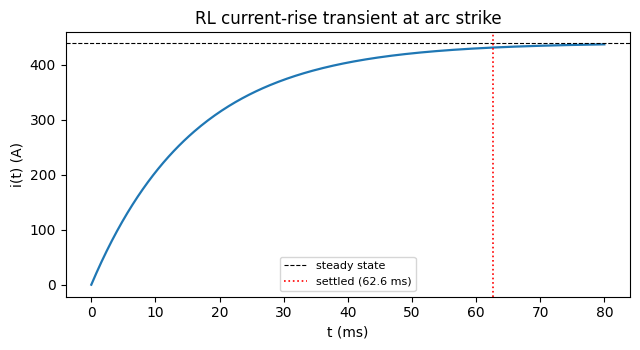

In [4]:
R_sec, L_leak = 0.05, 0.0008   # ohm, henry -- representative transformer secondary
t_settle = time_to_steady_state(R_sec, L_leak, tolerance=0.02)
print(f"R_secondary={R_sec} ohm, L_leakage={L_leak} H")
print(f"settles to within 2% of steady state in {t_settle*1000:.2f} ms")
print(f"-> {'UNDER 1 second' if t_settle < 1.0 else 'over 1 second'} (by a wide margin)")

t = np.linspace(0, 5 * (L_leak / R_sec), 300)
i_t = rl_transient_current(t, V=V_arc, R=R_sec, L=L_leak)
i_final = V_arc / R_sec

plt.figure(figsize=(6.5, 3.6))
plt.plot(t * 1000, i_t, lw=1.6)
plt.axhline(i_final, color='k', ls='--', lw=0.8, label='steady state')
plt.axvline(t_settle * 1000, color='r', ls=':', lw=1.2, label=f'settled ({t_settle*1000:.1f} ms)')
plt.xlabel('t (ms)'); plt.ylabel('i(t) (A)')
plt.title('RL current-rise transient at arc strike')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

In [5]:
# how much does doubling R change the settling time? (tau = L/R, so a lot)
for R_test in [R_sec, 2 * R_sec, 4 * R_sec]:
    t_test = time_to_steady_state(R_test, L_leak, tolerance=0.02)
    print(f"  R={R_test:.3f} ohm  ->  settling time = {t_test*1000:6.2f} ms")

  R=0.050 ohm  ->  settling time =  62.59 ms
  R=0.100 ohm  ->  settling time =  31.30 ms
  R=0.200 ohm  ->  settling time =  15.65 ms


## Part 3 -- Circuit engineering: transformer secondary impedance

$$Z_{\rm secondary} = R + j\omega L, \qquad V_{\rm arc} = V_{\rm open\,circuit} - I_{\rm weld}\,R_{\rm secondary}.$$

`transformer_secondary_impedance` reuses `dgs/ac_circuits.py`'s `impedance_L`
and `series_impedance` DIRECTLY (not reimplemented) -- the same RLC-impedance
machinery used elsewhere in this repo, applied to a welding transformer
instead of a generic filter. The voltage-drop relation explains a fact every
welder learns by feel: the rated open-circuit voltage on the nameplate is
never what the arc actually sees.

**What would I actually measure in a lab?** An impedance analyzer (or a
simple AC voltage/current ratio at a known frequency) across the open
secondary gives $|Z|$ directly; $V_{\rm open\,circuit}$ is read with no load
connected, $V_{\rm arc}$ with the arc struck -- the difference is exactly
$I\,R_{\rm secondary}$.

**MATLAB equivalent:** `Z = R + 1i*omega*L;` -- complex scalar arithmetic,
same as the Python here.

**Questions to ask:** Is $V_{\rm arc}$ always LESS than $V_{\rm open\,circuit}$
(yes, as long as $R_{\rm secondary}>0$ -- the secondary's own resistance always
eats some voltage)? Does the impedance's imaginary part matter for a DC-ish
welding current, or mostly for the AC transformer excitation itself (the
latter -- $\omega L$ is evaluated at the 60 Hz line frequency, not the
welding current, which is rectified/near-DC in most modern welders)?

Z_secondary(60 Hz) = 0.0500+0.3016j ohm   |Z| = 0.3057 ohm

V_open_circuit = 70.0 V (nameplate rating)
I_weld = 150.0 A
V_arc  = 62.50 V  (the 7.50 V difference is lost in R_secondary)


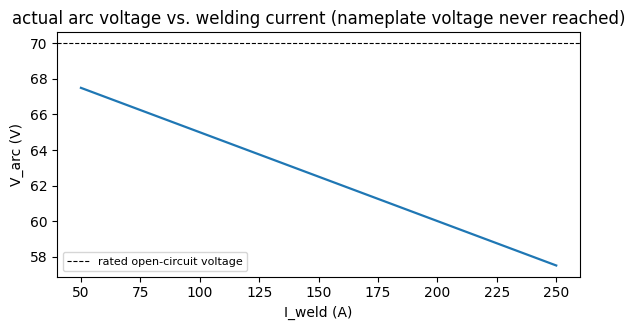

In [6]:
omega_60hz = 2 * np.pi * 60.0
Z_sec = transformer_secondary_impedance(R_sec, L_leak, omega_60hz)
print(f"Z_secondary(60 Hz) = {Z_sec:.4f} ohm   |Z| = {abs(Z_sec):.4f} ohm")

V_open_circuit = 70.0
V_arc_actual = open_circuit_to_arc_voltage_drop(V_open_circuit, I_weld, R_sec)
print(f"\nV_open_circuit = {V_open_circuit} V (nameplate rating)")
print(f"I_weld = {I_weld} A")
print(f"V_arc  = {V_arc_actual:.2f} V  (the {V_open_circuit - V_arc_actual:.2f} V difference is lost in R_secondary)")

I_range = np.linspace(50, 250, 50)
V_arc_range = [open_circuit_to_arc_voltage_drop(V_open_circuit, i, R_sec) for i in I_range]
plt.figure(figsize=(6, 3.4))
plt.plot(I_range, V_arc_range, lw=1.6)
plt.axhline(V_open_circuit, color='k', ls='--', lw=0.8, label='rated open-circuit voltage')
plt.xlabel('I_weld (A)'); plt.ylabel('V_arc (V)')
plt.title('actual arc voltage vs. welding current (nameplate voltage never reached)')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## Part 4 -- A practical number: heat input

$$HI = \frac{\eta\,V_{\rm arc}\,I_{\rm weld}}{v_{\rm travel}} \quad (\text{J/mm}).$$

An empirical process formula (not derived from the RL circuit above) that
welding procedure specifications actually use to bound penetration and
heat-affected-zone size -- $\eta\approx0.8$ is typical for SMAW/GMAW arcs.

**What would I actually measure in a lab?** $V_{\rm arc}$ and $I_{\rm weld}$
as in Part 1; travel speed with a stopwatch and ruler (or a robotic welder's
own speed setting) -- heat input itself is never measured directly, only
computed and compared against a weld procedure's allowed range.

**MATLAB equivalent:** `HI = eta*V*I/v;` -- one line, same as Python.

**Questions to ask:** Does a SLOWER travel speed increase or decrease heat
input (increase -- more time per unit length means more energy deposited per
unit length, even at the same power)? Is there a travel speed range a real
weld procedure would flag as "too hot" or "too cold" (yes -- shown below as
shaded regions on a representative procedure window)?

V_arc=22.0 V, I_weld=150.0 A, travel_speed=3.0 mm/s
heat input = 880.0 J/mm


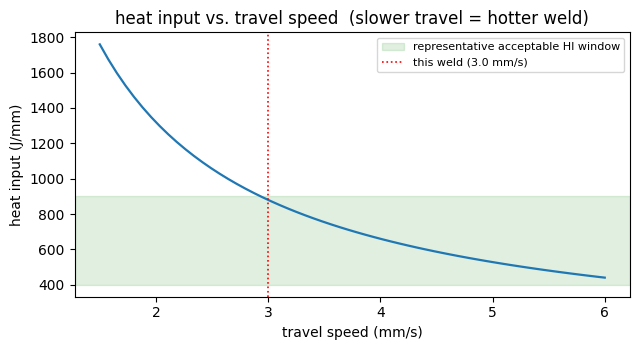

In [7]:
travel_speed = 3.0   # mm/s, typical manual SMAW travel speed
HI = heat_input(V_arc, I_weld, travel_speed)
print(f"V_arc={V_arc} V, I_weld={I_weld} A, travel_speed={travel_speed} mm/s")
print(f"heat input = {HI:.1f} J/mm")

speeds = np.linspace(1.5, 6.0, 60)
HI_range = [heat_input(V_arc, I_weld, s) for s in speeds]

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(speeds, HI_range, lw=1.6)
ax.axhspan(400, 900, color='green', alpha=0.12, label='representative acceptable HI window')
ax.axvline(travel_speed, color='r', ls=':', lw=1.2, label=f'this weld ({travel_speed} mm/s)')
ax.set_xlabel('travel speed (mm/s)'); ax.set_ylabel('heat input (J/mm)')
ax.set_title('heat input vs. travel speed  (slower travel = hotter weld)')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Summary

| Level | Quantity | Value (this notebook's numbers) |
|---|---|---|
| Algebra | $R_{\rm arc}$, $P_{\rm arc}$ | 0.147 ohm, 3300 W |
| Calculus | RL settling time | 62.6 ms -- well under 1 second |
| Circuit engineering | $Z_{\rm secondary}$(60 Hz), $V_{\rm arc}$ | $0.05+j0.30$ ohm, 62.5 V (vs. 70 V rated) |
| Practical | heat input | 880 J/mm |

Same circuit, same physical welder, four different questions -- each answered
at the level of math that actually answers it: algebra for instantaneous
Ohm's-law numbers, calculus for the transient's TIME BEHAVIOR, complex
impedance for the AC circuit's frequency-domain behavior, and one empirical
formula for the practical process-engineering number a weld shop actually
cares about.